In [5]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.metrics import r2_score
from sklearn.pipeline import Pipeline

In [11]:
X = 7 * np.random.rand(200, 1) - 3
y = 0.5 * X**2 + 0.6 * X + 2 + np.random.randn(200, 1) 

# y = 0.5x^2 + 0.6x + 2

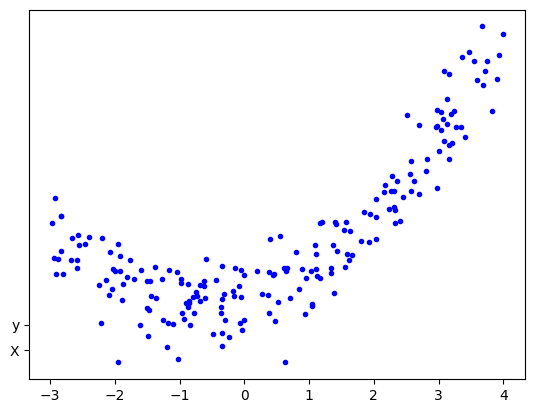

In [12]:
plt.plot(X, y, 'b.')
plt.plot("X")
plt.plot("y")
plt.show()

In [13]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 2)

In [28]:
polyn = PolynomialFeatures(degree=2, include_bias = True)
# By default include_bais is True
X_train_changed = polyn.fit_transform(X_train)
X_test_changed = polyn.transform(X_test)

In [29]:
# How X is transformed from 1 column to three
print(X_train[0])
print(X_train_changed[0])

[1.93602804]
[1.         1.93602804 3.74820456]


In [37]:
from sklearn.linear_model import LinearRegression, SGDRegressor

In [38]:
lr = LinearRegression()
lr.fit(X_train_changed,y_train)
y_pred = lr.predict(X_test_changed)

In [39]:
X_changed = np.linspace(-3,3,200).reshape(200,1)
X_changed_polyn = polyn.transform(X_changed)
y_changed = lr.predict(X_changed_polyn)

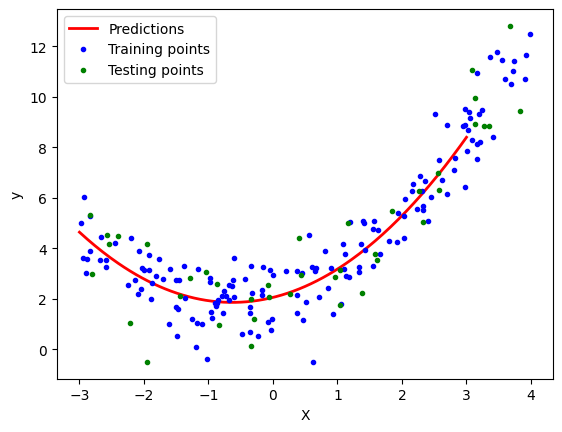

In [40]:

plt.plot(X_changed, y_changed, "r-", linewidth=2, label="Predictions")
plt.plot(X_train, y_train, "b.",label='Training points')
plt.plot(X_test, y_test, "g.",label='Testing points')
plt.xlabel("X")
plt.ylabel("y")
plt.legend()
plt.show()

In [48]:
# 3D Polynomial Regression using your variable style
import plotly.express as px
import plotly.graph_objects as go
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures

x = 7 * np.random.rand(100, 1) - 2.8
y = 7 * np.random.rand(100, 1) - 2.8
z = x**2 + y**2 + 0.2*x + 0.2*y + 0.1*x*y + 2 + np.random.randn(100, 1)
# Actual equation:
# z = x² + y² + 0.2x + 0.2y + 0.1xy + 2

X_multi = np.array([x, y]).reshape(100, 2)
poly = PolynomialFeatures(degree=2, include_bias=True)
X_multi_changed = poly.fit_transform(X_multi)
print("Input Features :", poly.n_features_in_)
print("Output Features :", poly.n_output_features_)
print("Powers\n", poly.powers_)

lr = LinearRegression()
lr.fit(X_multi_changed, z)

x_input = np.linspace(x.min(), x.max(), 20)
y_input = np.linspace(y.min(), y.max(), 20)

xGrid, yGrid = np.meshgrid(x_input, y_input)

# converting grid into prediction input format

final_input = np.vstack((xGrid.ravel(),yGrid.ravel())).T
final_input_poly = poly.transform(final_input)
z_final = lr.predict(final_input_poly).reshape(20, 20)

import plotly.io as pio
pio.renderers.default = "browser"
fig = px.scatter_3d(x=x.ravel(),y=y.ravel(),z=z.ravel())
fig.add_trace(go.Surface(x=x_input,y=y_input,z=z_final))
fig.update_layout(scene=dict(zaxis=dict(range=[0, 35])))
fig.show()

Input Features : 2
Output Features : 6
Powers
 [[0 0]
 [1 0]
 [0 1]
 [2 0]
 [1 1]
 [0 2]]
